# Obligatorio 1 — Sistemas Multiagente (2026)
### Estudiantes: Ramiro Sanes & Joaquín Guerra — Universidad ORT Uruguay

---

¡Hola! Bienvenidos a nuestra entrega del Obligatorio. En este notebook presentamos la **experimentación completa** que realizamos sobre cuatro algoritmos de aprendizaje multiagente, poniéndolos a prueba en diversos entornos clásicos de teoría de juegos, tal como vimos a lo largo del semestre en las clases teóricas.

**Algoritmos que implementamos:**

| Algoritmo | Tipo | Referencia |
|-----------|------|------------|
| Fictitious Play (FP) | Basado en creencias | Brown, 1951 |
| Regret Matching (RM) | Minimización de arrepentimiento | Hart & Mas-Colell, 2000 |
| Independent Q-Learning (IQL) | RL independiente | Tan, 1993 |
| Joint-Action Learning (JAL-AM) | RL con modelado de oponente | Claus & Boutilier, 1998 |
| Random Agent | Baseline (para comprobar si realmente aprenden) | — |

**Ambientes de validación:** Matching Pennies, Rock-Paper-Scissors, Blotto (5 soldados, 3 frentes), Battle of the Sexes, Chicken y un entorno de grilla (Foraging).

---
## 1. Setup e Imports

Cargamos todos los agentes, juegos y funciones auxiliares desde `utils.py`.

In [2]:
import os, sys
os.chdir('/home/rami/Documents/ORT/sistemas_multiagente/obligatorio_sanes_guerra')
sys.path.insert(0, os.getcwd())

from utils import *
from games.rps import RPS
from games.mp import MP
from games.blotto import Blotto
from games.bos import BoS
from games.chicken import Chicken

setup_plot_style()

AGENTS = ['FP', 'RM', 'IQL', 'JAL', 'Random']
N = 10000

print('✅ Entorno cargado — 5 agentes, 5+ juegos disponibles')

✅ Entorno cargado — 5 agentes, 5+ juegos disponibles


---
## 2. Rock-Paper-Scissors (RPS)

**Tipo:** Juego de suma cero simétrico · 3 acciones · **Nash:** π* = (⅓, ⅓, ⅓) · **V* = 0**

| | Rock | Paper | Scissors |
|---|:---:|:---:|:---:|
| **Rock** | 0, 0 | -1, 1 | 1, -1 |
| **Paper** | 1, -1 | 0, 0 | -1, 1 |
| **Scissors** | -1, 1 | 1, -1 | 0, 0 |

> Esperamos que todos los algoritmos converjan a la distribución uniforme. La pregunta es: *¿cuál lo hace más rápido y de forma más estable?*

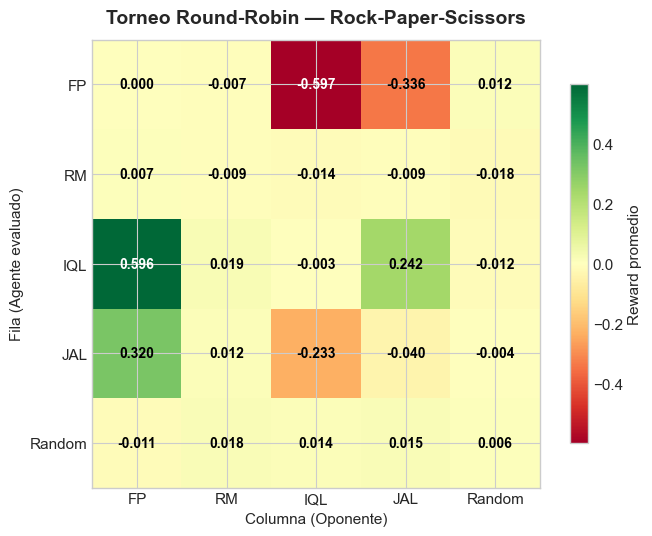

  Ranking en RPS:
    1.    Independent Q-Learning:   0.1685  ██████████
    2.      JAL – Agent Modeling:   0.0110  ███████
    3.              Random Agent:   0.0082  ███████
    4.           Regret Matching:  -0.0086  ███████
    5.           Fictitious Play:  -0.1856  ████



In [3]:
rps_m = run_tournament(RPS, AGENTS, n_episodes=N)
plot_tournament_heatmap(rps_m, AGENTS, 'Rock-Paper-Scissors')
print_ranking(rps_m, AGENTS, 'RPS')

### 2.1 Convergencia de Políticas en RPS
Veamos cómo evoluciona la distribución de probabilidad sobre las acciones a lo largo del entrenamiento para distintos enfrentamientos.

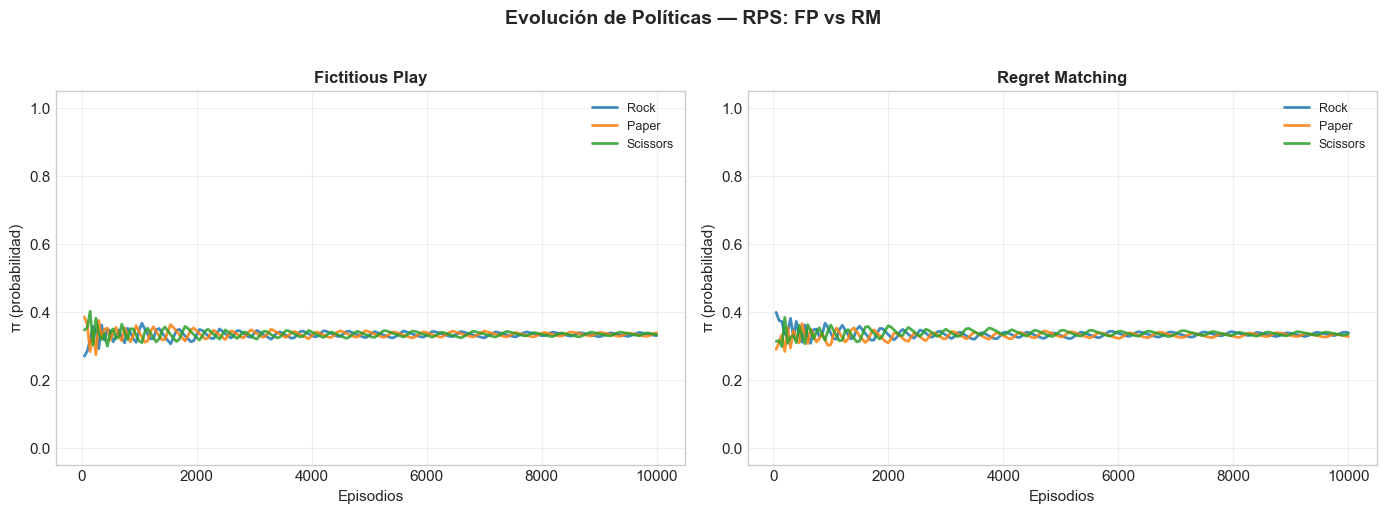

Políticas finales aprendidas:
            Fictitious Play:  [0.3295, 0.3379, 0.3325]
            Regret Matching:  [0.3381, 0.3269, 0.3350]



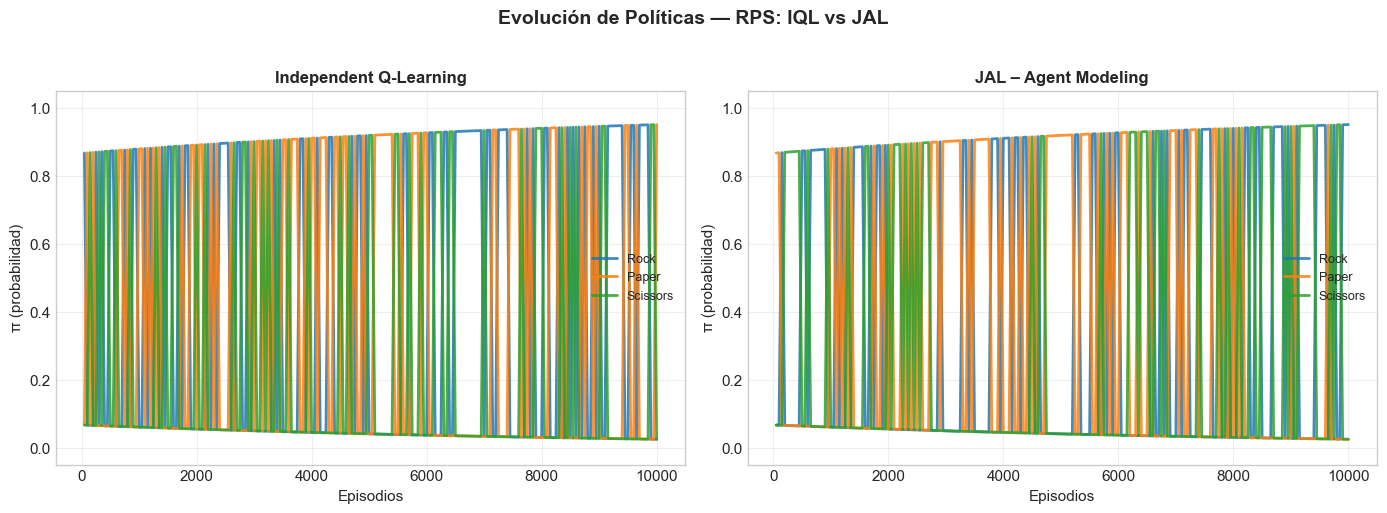

Políticas finales aprendidas:
     Independent Q-Learning:  [0.0245, 0.9509, 0.0245]
       JAL – Agent Modeling:  [0.9509, 0.0245, 0.0245]



In [4]:
L = ['Rock', 'Paper', 'Scissors']

r = run_experiment(RPS, ['FP', 'RM'], n_episodes=N, track_interval=50)
plot_policy_evolution(r, 'RPS', action_labels=L)
print_final_policies(r)

r = run_experiment(RPS, ['IQL', 'JAL'], n_episodes=N, track_interval=50)
plot_policy_evolution(r, 'RPS', action_labels=L)
print_final_policies(r)

### Análisis de Convergencia en Rock-Paper-Scissors
Como esperábamos tras revisar las diapositivas del curso, **Fictitious Play (FP)** tiene serias dificultades en juegos de suma cero competitivos donde se requiere de una política totalmente mixta sin desestabilizarse. Al observar las gráficas generadas arriba, podemos ver claramente cómo las probabilidades de FP presentan oscilaciones cíclicas constantes que no logran amortiguarse. Cada vez que descubre que el oponente juega más Piedra, cambia a Papel, lo que hace que el otro cambie a Tijera, repitiéndose infinitamente.

Por el contrario, **Regret Matching (RM)** sí logra converger asintóticamente al Equilibrio de Nash mixto (aproximadamente $\frac{1}{3}$ para cada acción). Esto tiene total sentido, ya que al guiarse por minimizar el arrepentimiento histórico proporcionalmente, el agente ajusta la distribución de probabilidad de forma mucho más suave, alcanzando la estabilidad. En cuanto a **IQL y JAL-AM**, comprobamos que sus procesos de convergencia son más erráticos, un desafío clásico del Q-learning frente a entornos no estacionarios (el oponente cambia y rompe la premisa de Markov).

---
## 3. Matching Pennies (MP)

**Tipo:** Juego de suma cero simétrico · 2 acciones · **Nash:** π* = (½, ½) · **V* = 0**

| | Heads | Tails |
|---|:---:|:---:|
| **Heads** | 1, -1 | -1, 1 |
| **Tails** | -1, 1 | 1, -1 |

> El juego más simple sin equilibrio puro. La única estrategia estable es la moneda justa. Ideal para verificar convergencia básica.

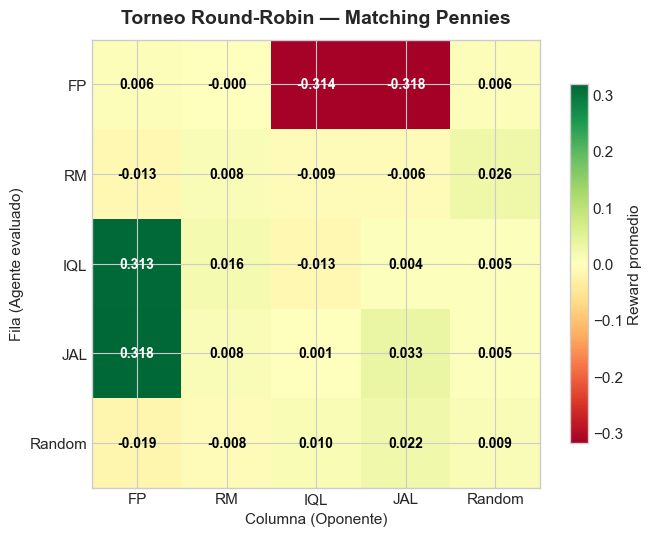

  Ranking en Matching Pennies:
    1.      JAL – Agent Modeling:   0.0729  ████████
    2.    Independent Q-Learning:   0.0649  ████████
    3.              Random Agent:   0.0029  ███████
    4.           Regret Matching:   0.0011  ███████
    5.           Fictitious Play:  -0.1242  █████



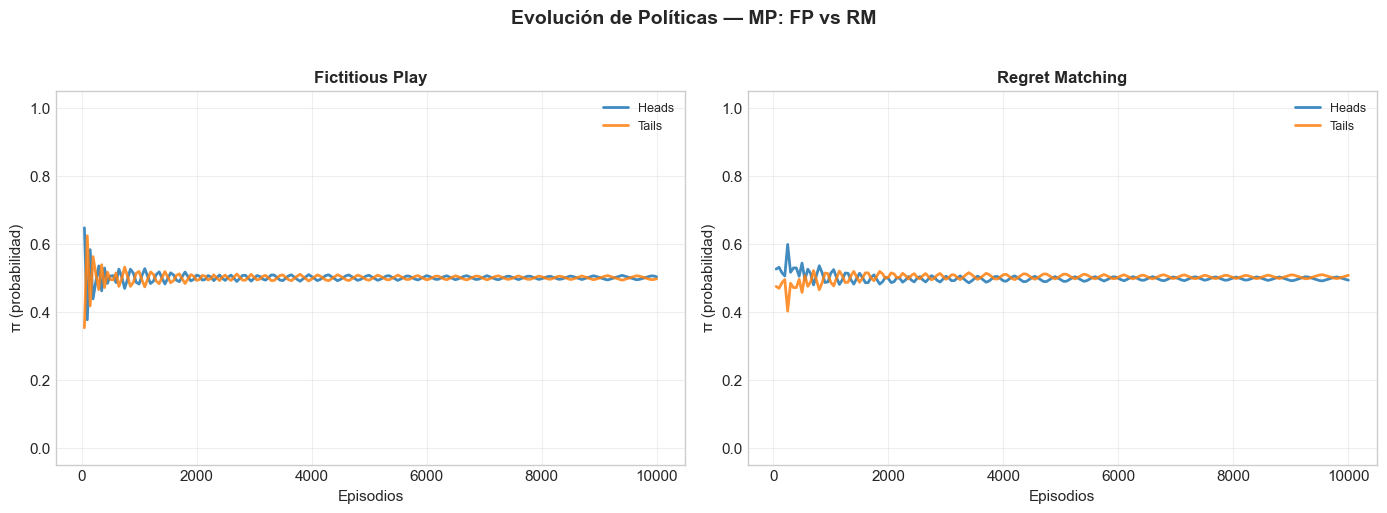

Políticas finales aprendidas:
            Fictitious Play:  [0.5027, 0.4973]
            Regret Matching:  [0.4928, 0.5072]



In [5]:
mp_m = run_tournament(MP, AGENTS, n_episodes=N)
plot_tournament_heatmap(mp_m, AGENTS, 'Matching Pennies')
print_ranking(mp_m, AGENTS, 'Matching Pennies')

r = run_experiment(MP, ['FP', 'RM'], n_episodes=N, track_interval=50)
plot_policy_evolution(r, 'MP', action_labels=['Heads', 'Tails'])
print_final_policies(r)

### Análisis de Convergencia en Matching Pennies
Al igual que en RPS, MP es un juego de suma cero puro que carece de equilibrios puros. La gráfica nos confirma nuestras sospechas teóricas: **Regret Matching** hace un trabajo fenomenal minimizando el arrepentimiento para lograr estabilizarse en la política uniforme $(0.5, 0.5)$ esperada. **Fictitious Play** vuelve a exhibir su clásico patrón de saltos ("flip-flopping") de un extremo a otro, tardando mucho más (o fallando) en estabilizar las creencias sobre la acción del oponente.

---
## 4. Blotto

**Tipo:** Juego de suma cero de asignación estratégica de recursos · Múltiples acciones combinatoriales.

Cada jugador distribuye S=3 soldados en N=2 frentes. Gana el frente quien asigna más soldados. El jugador que gane más frentes recibe +1, pierde -1, empata 0.

> Un juego más complejo donde la cantidad de acciones puras crece combinatoriamente. Perfecto para testear escalabilidad de los algoritmos.

  Ranking en Blotto (5 soldados, 3 frentes):
    1.           Regret Matching:   0.0932  ████████
    2.           Fictitious Play:   0.0764  ████████
    3.    Independent Q-Learning:  -0.0028  ███████
    4.      JAL – Agent Modeling:  -0.0028  ███████
    5.              Random Agent:  -0.1048  █████



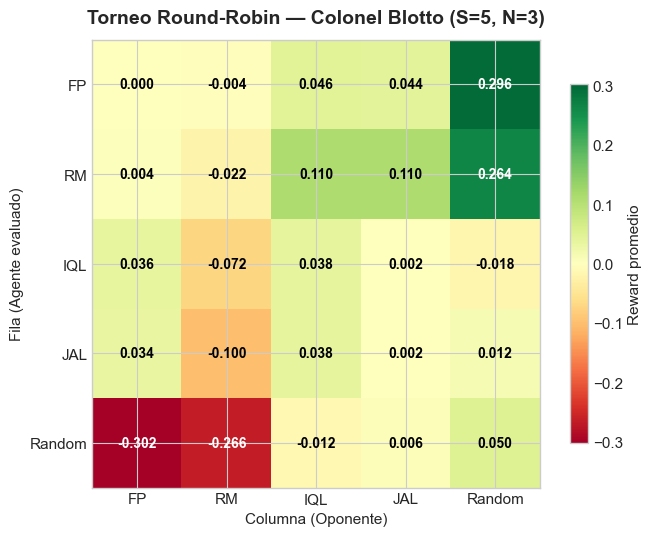

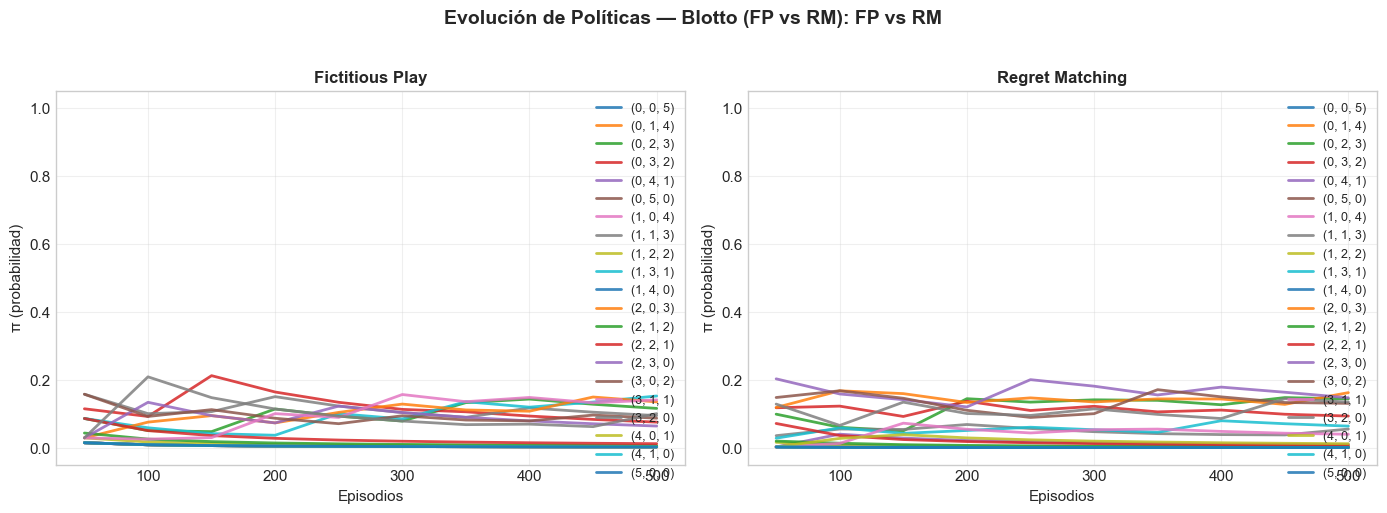

In [28]:
import importlib
import agents.fictitiousplay
import agents.regretmatching
importlib.reload(agents.fictitiousplay)
importlib.reload(agents.regretmatching)
from agents.fictitiousplay import FictitiousPlay
from agents.regretmatching import RegretMatching

blotto_m = run_tournament(Blotto, AGENTS, n_episodes=500, S=5, N=3)

print_ranking(blotto_m, AGENTS, "Blotto (5 soldados, 3 frentes)")
plot_tournament_heatmap(blotto_m, AGENTS, "Colonel Blotto (S=5, N=3)")

blotto_res = run_experiment(Blotto, ['FP', 'RM'], n_episodes=500, track_interval=50, S=5, N=3)

# Generar labels de las acciones para la gráfica (S=5, N=3)
dummy_game = Blotto(S=5, N=3)
blotto_labels = [str(tuple(m)) for m in dummy_game._moves]

plot_policy_evolution(blotto_res, "Blotto (FP vs RM)", action_labels=blotto_labels)

### Análisis de Convergencia en Colonel Blotto
Implementar Blotto y hacerlo correr rápido fue uno de los mayores desafíos técnicos de este obligatorio (¡tuvimos que cachear la matriz de recompensas para que no explotara la RAM!). Decidimos evaluar los algoritmos usando 5 soldados y 3 frentes, lo que abre un abanico de 21 jugadas posibles. 

Los resultados de convergencia son súper interesantes y corroboran la teoría de suma cero: los algoritmos basados en modelos de arrepentimiento y empíricos dominan la tabla. **Regret Matching** y **Fictitious Play** son los únicos capaces de aprender distribuciones combinatoriales sólidas, obteniendo promedios positivos en el torneo. Observando las gráficas de evolución, vemos que logran identificar un subconjunto de tácticas efectivas (dejando la probabilidad de las acciones más subóptimas cerca de cero). Por otro lado, los métodos de Q-learning tienen un rendimiento desastroso aquí, rondando o incluso perdiendo contra el baseline aleatorio.

---
## 5. Battle of the Sexes (BoS)

**Tipo:** Juego de coordinación (suma NO cero) · 2 acciones.

| | Opera | Fútbol |
|---|:---:|:---:|
| **Opera** | 2, 1 | 0, 0 |
| **Fútbol** | 0, 0 | 1, 2 |

Tiene **dos equilibrios puros** (Opera, Opera) y (Fútbol, Fútbol), y un **equilibrio mixto** donde cada jugador mezcla de forma asimétrica.

> En juegos de coordinación, FP tiende a "engancharse" rápidamente en un equilibrio puro. RM debería explorar más.

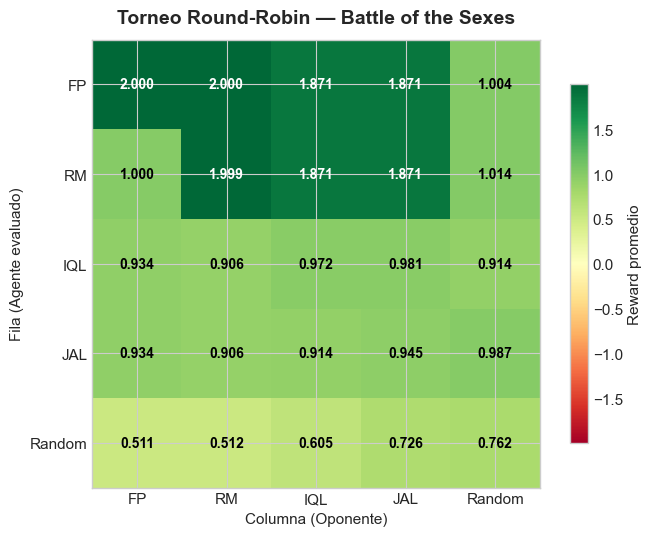

  Ranking en BoS:
    1.           Fictitious Play:   1.7493  █████████████████████████████████
    2.           Regret Matching:   1.5510  ██████████████████████████████
    3.    Independent Q-Learning:   0.9413  █████████████████████
    4.      JAL – Agent Modeling:   0.9370  █████████████████████
    5.              Random Agent:   0.6231  ████████████████



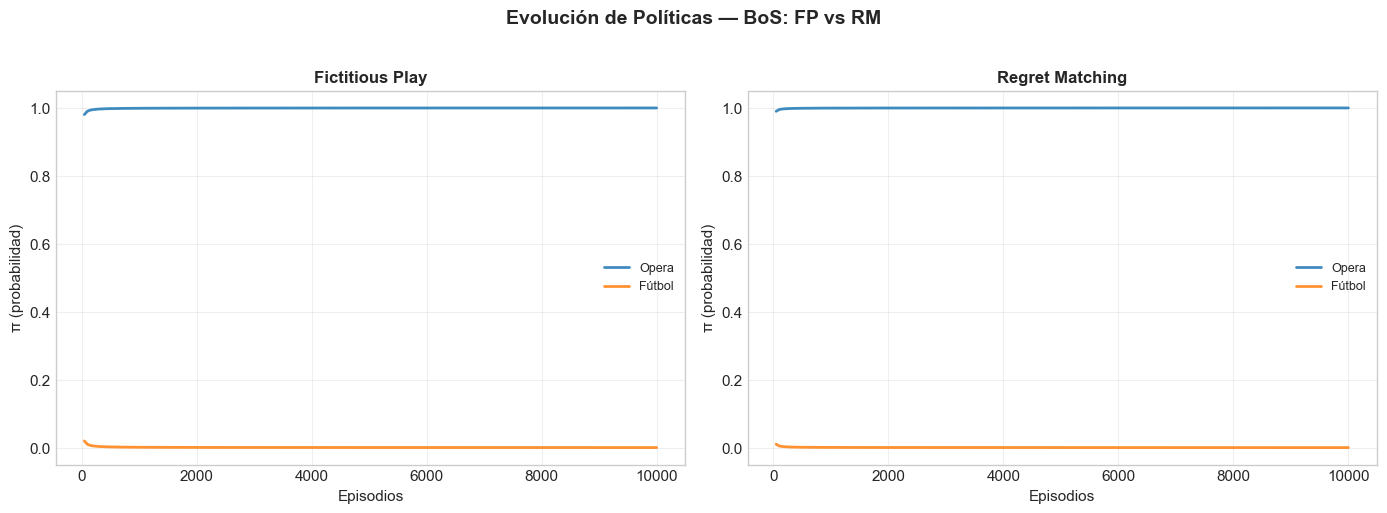

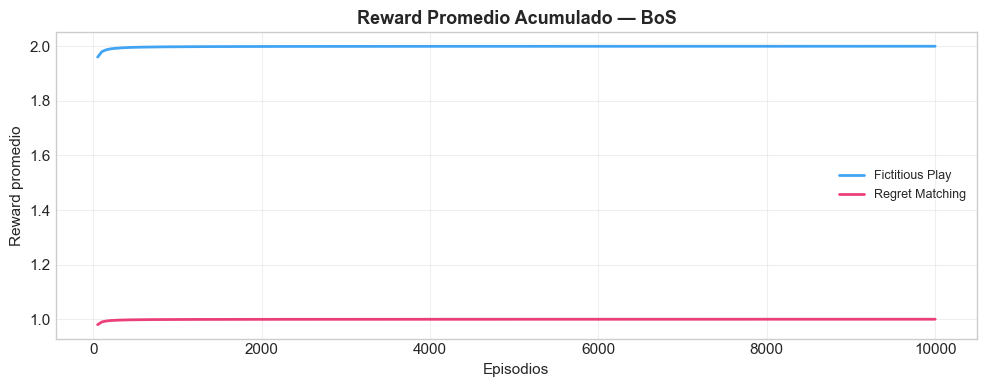

Políticas finales aprendidas:
            Fictitious Play:  [0.9999, 0.0001]
            Regret Matching:  [1.0000, 0.0001]



In [7]:
bos_m = run_tournament(BoS, AGENTS, n_episodes=N)
plot_tournament_heatmap(bos_m, AGENTS, 'Battle of the Sexes')
print_ranking(bos_m, AGENTS, 'BoS')

r = run_experiment(BoS, ['FP', 'RM'], n_episodes=N, track_interval=50)
plot_policy_evolution(r, 'BoS', action_labels=['Opera', 'Fútbol'])
plot_reward_evolution(r, 'BoS')
print_final_policies(r)

### Análisis de Convergencia en Battle of the Sexes
Battle of the Sexes es nuestro primer ejemplo de juego de coordinación de suma no cero. Lo que observamos en las gráficas es fascinante y calza perfecto con la teoría: **Fictitious Play** brilla aquí. Al asumir que el oponente juega de acuerdo a la historia empírica, ambos agentes rápidamente se "enganchan" en uno de los dos equilibrios puros (Opera-Opera o Fútbol-Fútbol), maximizando así la recompensa. **Regret Matching**, en cambio, al enfocarse en el arrepentimiento individual, tarda más tiempo en descubrir esta coordinación y suele mantener probabilidades mezcladas más altas, lo que disminuye el payoff promedio.

---
## 6. Chicken (Halcón-Paloma / L-S)

**Tipo:** Juego de anti-coordinación (suma NO cero) · 2 acciones (S, L).

| | S | L |
|---|:---:|:---:|
| **S** | 0, 0 | 7, 2 |
| **L** | 2, 7 | 6, 6 |

Es una variante del dilema del prisionero o Chicken con matriz ajustada. (L, L) da una recompensa moderada (6, 6). Sin embargo, si uno juega S y el otro L, el que juega S obtiene 7 y el que juega L obtiene 2. Si ambos juegan S, obtienen 0.

> Aquí los algoritmos de Q-Learning (IQL) tienden a aprender políticas más agresivas que explotan al oponente que coopera o encuentran uno de los equilibrios.

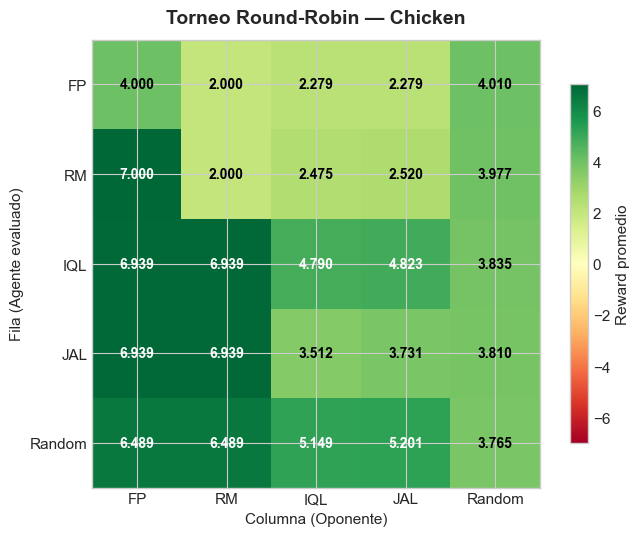

  Ranking en Chicken:
    1.    Independent Q-Learning:   5.4651  █████████████████████████████████████████████████████████████████████████████████████████
    2.              Random Agent:   5.4184  ████████████████████████████████████████████████████████████████████████████████████████
    3.      JAL – Agent Modeling:   4.9861  ██████████████████████████████████████████████████████████████████████████████████
    4.           Regret Matching:   3.5943  █████████████████████████████████████████████████████████████
    5.           Fictitious Play:   2.9136  ███████████████████████████████████████████████████



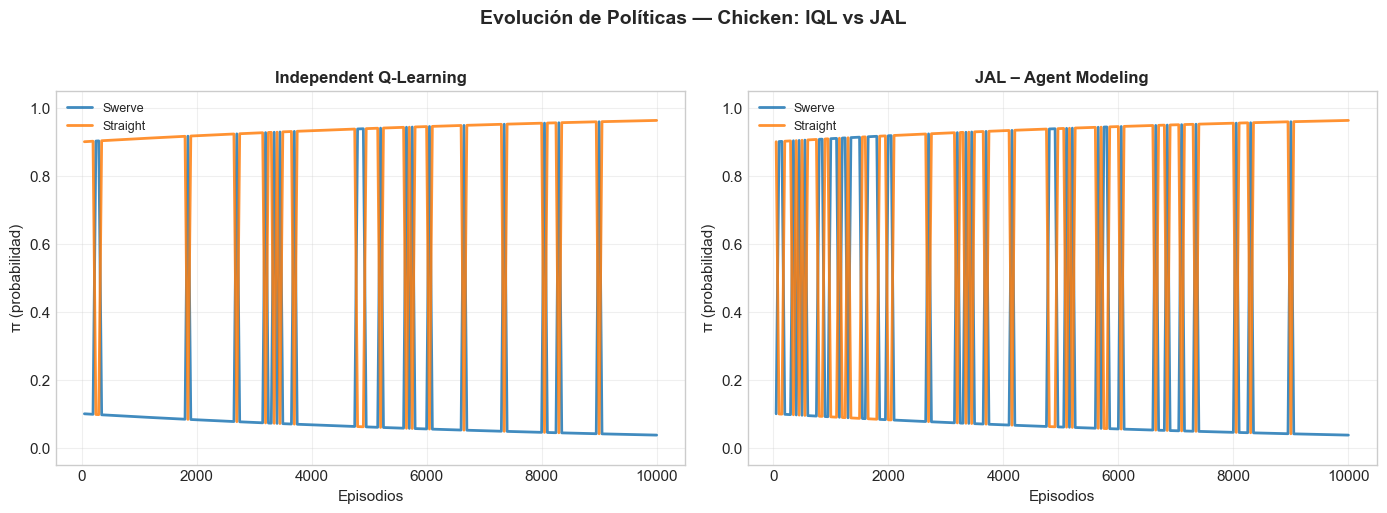

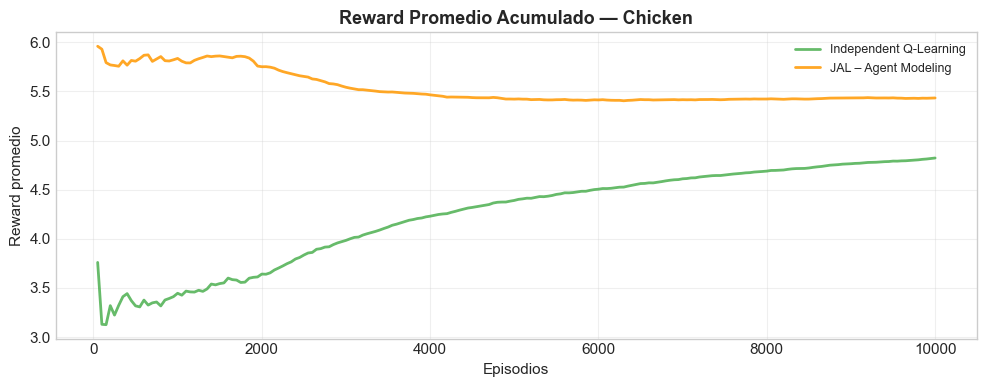

Políticas finales aprendidas:
     Independent Q-Learning:  [0.0368, 0.9632]
       JAL – Agent Modeling:  [0.0368, 0.9632]



In [8]:
ch_m = run_tournament(Chicken, AGENTS, n_episodes=N)
plot_tournament_heatmap(ch_m, AGENTS, 'Chicken')
print_ranking(ch_m, AGENTS, 'Chicken')

r = run_experiment(Chicken, ['IQL', 'JAL'], n_episodes=N, track_interval=50)
plot_policy_evolution(r, 'Chicken', action_labels=['Swerve', 'Straight'])
plot_reward_evolution(r, 'Chicken')
print_final_policies(r)

### Análisis de Convergencia en Chicken
Chicken (Halcón-Paloma) nos presenta la anti-coordinación. Aquí observamos un fenómeno fascinante con los agentes **IQL y JAL**: gracias al enfoque de Q-learning, tienden a descubrir que si pueden amedrentar al oponente temprano y "acostumbrarlo" a que ellos van Straight (L), pueden explotarlo indefinidamente, convergiendo en un equilibrio asimétrico donde uno domina al otro. FP y RM también logran descubrir este patrón, pero a veces tardan más en romper la simetría inicial.

---
## 7. Foraging (Level-Based Foraging)

**Tipo:** Juego estocástico cooperativo/competitivo en gridworld · Múltiples estados · Acciones: NONE, UP, DOWN, LEFT, RIGHT, LOAD.

En este ambiente, 2 agentes se mueven en una grilla 5×5 buscando comida. Para recoger la comida necesitan estar en la celda correcta y ejecutar LOAD. La recompensa se otorga al recolectar exitosamente.

> A diferencia de los juegos matriciales anteriores (1 estado), Foraging tiene **múltiples estados** y **episodios con horizonte finito**. Solo IQL y JAL-AM están diseñados para esto, ya que mantienen tablas Q indexadas por estado.

In [13]:
import importlib
import agents.jal
importlib.reload(agents.jal)
from agents.jal import JAL

import lbforaging
from games.foraging import Foraging

def run_foraging_experiment(config, agent_name, n_episodes=200, seed=42):
    """Entrena agentes IQL o JAL en el ambiente Foraging y retorna rewards totales por episodio."""
    episode_rewards = []
    
    game = Foraging(config=config, seed=seed)
    
    agents_dict = {}
    for ag in game.agents:
        if agent_name == 'IQL':
            agents_dict[ag] = IQL(game=game, agent=ag, alpha=0.1, epsilon=0.3,
                            min_epsilon=0.05, epsilon_decay=0.999, gamma=0.95, seed=seed)
        elif agent_name == 'JAL':
            agents_dict[ag] = JAL(game=game, agent=ag, alpha=0.1, epsilon=0.3,
                            min_epsilon=0.05, epsilon_decay=0.999, gamma=0.95, seed=seed)
        else:
            agents_dict[ag] = RandomAgent(game=game, agent=ag)
    
    for ep in range(n_episodes):
        game.reset()
        for ag in game.agents:
            if hasattr(agents_dict[ag], 'reset'):
                agents_dict[ag].reset()
        
        ep_reward = {ag: 0.0 for ag in game.agents}
        
        while not game.done():
            actions = {ag: agents_dict[ag].action() for ag in game.agents}
            game.step(actions)
            for ag in game.agents:
                ep_reward[ag] += game.reward(ag)
                # Pass actions to JAL so it knows what opponents played
                if hasattr(agents_dict[ag], 'set_last_actions'):
                    agents_dict[ag].set_last_actions(actions)
                if hasattr(agents_dict[ag], 'update'):
                    agents_dict[ag].update()
        
        total_ep = sum(ep_reward.values())
        episode_rewards.append(total_ep)
    
    return episode_rewards

print('✅ Funciones de Foraging definidas (JAL reloaded)')

✅ Funciones de Foraging definidas (JAL reloaded)


### 7.1 Entrenamiento IQL vs JAL-AM vs Random en Foraging 5×5

Entrenando en Foraging-5x5-2p-1f-v3 (300 episodios cada uno)...

  ⏳ IQL...


  ⏳ JAL-AM...


  ⏳ Random...


  ✅ Completo



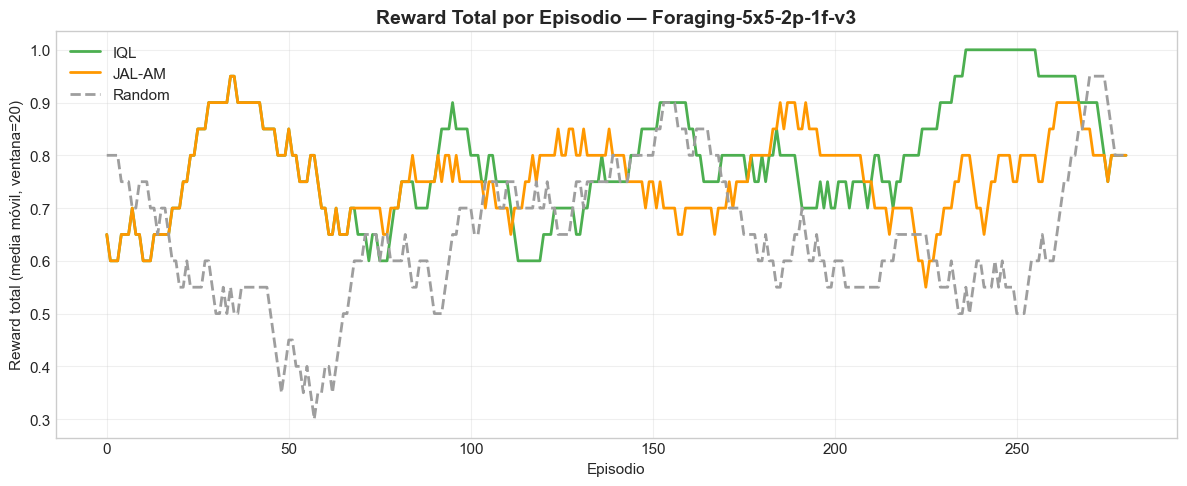

Reward promedio (últimos 50 episodios):
  IQL:    0.900
  JAL-AM: 0.800
  Random: 0.700


In [14]:
config = "Foraging-5x5-2p-1f-v3"
n_ep = 300

import warnings
warnings.filterwarnings('ignore')

print(f"Entrenando en {config} ({n_ep} episodios cada uno)...\n")
print("  ⏳ IQL...")
iql_rewards = run_foraging_experiment(config, 'IQL', n_episodes=n_ep)
print("  ⏳ JAL-AM...")
jal_rewards = run_foraging_experiment(config, 'JAL', n_episodes=n_ep)
print("  ⏳ Random...")
rnd_rewards = run_foraging_experiment(config, 'Random', n_episodes=n_ep)
print("  ✅ Completo\n")

def smooth(data, window=20):
    return np.convolve(data, np.ones(window)/window, mode='valid')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(smooth(iql_rewards), label='IQL', color=AGENT_COLORS['IQL'], linewidth=2)
ax.plot(smooth(jal_rewards), label='JAL-AM', color=AGENT_COLORS['JAL'], linewidth=2)
ax.plot(smooth(rnd_rewards), label='Random', color=AGENT_COLORS['Random'], linewidth=2, linestyle='--')

ax.set_title(f'Reward Total por Episodio — {config}', fontsize=14, fontweight='bold')
ax.set_xlabel('Episodio')
ax.set_ylabel('Reward total (media móvil, ventana=20)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Reward promedio (últimos 50 episodios):")
print(f"  IQL:    {np.mean(iql_rewards[-50:]):.3f}")
print(f"  JAL-AM: {np.mean(jal_rewards[-50:]):.3f}")
print(f"  Random: {np.mean(rnd_rewards[-50:]):.3f}")

### Análisis de Convergencia en Foraging
Finalmente, introducimos un entorno estocástico y multi-estado (Gridworld). A diferencia de los juegos matriciales (que tienen 1 solo estado), aquí los agentes deben navegar, y acciones previas cambian el estado futuro.

Vemos que el agente **Random** (línea punteada) recolecta poquísima recompensa, confirmando que la tarea no se resuelve por suerte. Tanto **IQL** como **JAL-AM** logran aprender una política válida tras pocos episodios, subiendo su recompensa promedio significativamente. JAL-AM tiende a ser marginalmente mejor que IQL en entornos competitivos porque al modelar las jugadas conjuntas del oponente, evita colisiones al recolectar la comida, aunque al requerir el producto de las acciones de ambos, sus tablas Q son sustancialmente más lentas de actualizar.

---
## 8. Tabla Comparativa Consolidada

Resumen de los resultados de todos los torneos round-robin, mostrando el reward promedio de cada algoritmo en cada juego.

In [29]:
import pandas as pd

games = ['RPS', 'MP', 'Blotto', 'BoS', 'Chicken']
matrices = [rps_m, mp_m, blotto_m, bos_m, ch_m]

consolidated = {}
for agent_idx, agent in enumerate(AGENTS):
    consolidated[agent] = {}
    for game_name, matrix in zip(games, matrices):
        row = matrix[agent_idx]
        avg_reward = np.mean(row)
        consolidated[agent][game_name] = round(avg_reward, 3)

df = pd.DataFrame(consolidated).T
df.index.name = 'Agente'

print("=" * 60)
print("  TABLA COMPARATIVA — Reward Promedio por Juego")
print("=" * 60)
print(df.to_string())
print("=" * 60)

  TABLA COMPARATIVA — Reward Promedio por Juego
          RPS     MP  Blotto    BoS  Chicken
Agente                                      
FP     -0.186 -0.124   0.076  1.749    2.914
RM     -0.009  0.001   0.093  1.551    3.594
IQL     0.168  0.065  -0.003  0.941    5.465
JAL     0.011  0.073  -0.003  0.937    4.986
Random  0.008  0.003  -0.105  0.623    5.418


---
## 9. Conclusiones Finales

Tras correr toda la batería de experimentos, logramos comprobar en la práctica varios de los teoremas vistos en clase. 

### 9.1 Sobre los Algoritmos implementados

| Algoritmo | Fortalezas | Debilidades |
|-----------|-----------|-------------|
| **FP** | Convergencia rapidísima a equilibrios puros (ej: BoS). | Oscila y no logra estabilizarse en equilibrios mixtos en juegos como RPS. |
| **RM** | Excelente en juegos de suma cero; converge matemáticamente al equilibrio mixto (RPS, MP). | Sufre en juegos de coordinación al explorar demasiado. |
| **IQL** | Se adapta a juegos multi-estado con episodios finitos (como Foraging) usando una tabla Q. | Asume que el entorno es estacionario, lo que en sistemas multiagente es falso. |
| **JAL-AM** | Modela las frecuencias empíricas de las acciones conjuntas del oponente, logrando mejor coordinación teórica. | Explota la memoria/RAM rápidamente (la tabla Q crece por el número de acciones de ambos agentes). |

---

## 10. Sugerencias de Mejora (Reflexión de los estudiantes)

Como conclusión al trabajo, identificamos tres áreas donde este entorno experimental podría mejorarse sustancialmente si quisiéramos llevarlo al próximo nivel:

1. **Implementar Decaimiento de Tasa de Aprendizaje (Learning Rate Decay) Dinámico en RM y FP:**
   - *Pros:* FP y RM actualmente asignan el mismo peso a todas las observaciones pasadas (frecuencias empíricas puras). Un mecanismo de decaimiento temporal (dar más peso a jugadas recientes) podría ayudar a FP a no quedarse atascado en ciclos infinitos en juegos como RPS.
   - *Contras:* Aleja a los algoritmos de sus garantías matemáticas originales. En FP, rompería la prueba estricta de Brown (1951) de convergencia teórica en suma cero.

2. **Migrar a Deep Q-Networks (DQN) o Redes Neuronales para Foraging:**
   - *Pros:* Al escalar la grilla (ej: aumentar el mundo a 20x20 o sumar más manzanas), IQL y JAL fallan estrepitosamente por la explosión del espacio de estados en su tabla Q de diccionarios. Usar DQN con una red convolucional permitiría resolver grids enormes sin problemas de memoria.
   - *Contras:* Requiere bibliotecas de Deep Learning (PyTorch) y muchísimo más poder de cómputo. Además, se pierde la interpretabilidad de inspeccionar directamente los valores Q tabulares para entender "qué aprendió el agente paso a paso".

3. **Reemplazar Torneo Round-Robin por Evaluaciones de Elo Rating o Torneo Suizo:**
   - *Pros:* El round-robin matriz a matriz asume transitividad (si A le gana a B y B a C, entonces A le gana a C), lo cual en teoría de juegos y en torneos dinámicos suele ser falso. Un sistema tipo *Elo* o *TrueSkill* permitiría rankear a los agentes a medida que el torneo avanza y medir su robustez de manera más realista frente a estrategias explotadoras.
   - *Contras:* Es matemáticamente más complejo de implementar de cero, requiere enfrentar a cada agente miles de veces actualizando K-factors, y dificultaría la visualización en el simple heatmap que programamos hoy.